# Week 4 Day 4 Lab


### Problem 1
1. Pick a dataset you have not used yet from our collection of datasets: [click here for link](https://github.com/garrett-kepler/Math-300----Mathematical-Computing/tree/main/Datasets).
2. Load the dataset into your notebook
3. Plot a feature of the dataset against another feature.
4. Does there seem to be a relationship?

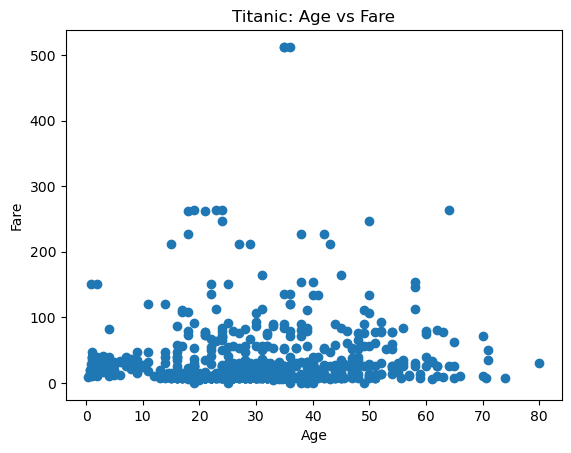

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#1 
#Titanic data set

#2
df = pd.read_csv('/Users/lukelewis/Downloads/Math300_Week3/titanic.csv') 

df = df[['Age', 'Fare']].dropna()

#3
plt.scatter(df['Age'], df['Fare']) 
plt.xlabel('Age') 
plt.ylabel('Fare') 
plt.title('Titanic: Age vs Fare')
plt.show()

In [ ]:
#4
# The scatter plot shows a weak positive relationship between age and fare. 
# While passengers who paid higher fares appear at many different ages, there is no strong linear pattern.
# Most passengers paid relatively low fares regardless of age, with a couple high-fare outliers.
# This shows that age is not a strong predictor of ticket fare.


### Problem 2
1. Compute the correlation between all the features.
2. What is the largest correlated/anti-correlated features?
3. Do you have an explanation for why?

In [3]:
#1
df = pd.read_csv('/Users/lukelewis/Downloads/Math300_Week3/titanic.csv')

corr = df.corr(numeric_only=True) 
print(corr)

corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

corr_pairs = corr_pairs.drop_duplicates()

print('\nLargest Positive Correlation:')
print(corr_pairs.sort_values(ascending=False).head())

print('\nNegative Correlation:')
print(corr_pairs.sort_values().head())

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  

Largest Positive Correlation:
SibSp     Parch    0.414838
Survived  Fare     0.257307
Parch     Fare     0.216225
SibSp     Fare     0.159651
Age       Fare     0.096067
dtype: float

In [ ]:
#2
# The largest positive correlation is between Sibsp and Parch, with a correlation of 0.414838.
# The largest negative correlation is between Pclass and Fare, with a correlation of -0.549500.

#3
# Sibsp and Parch are positively correlated because families often traveled together on the titanic, so passengers with siblings or spouses were also more likely to be traveling with parents or children.
# Pclass and Fare are negatively correlated because first-class passengers generally paid higher ticket prices, while third-class passengers paid lower fares creating a strong negative relationship between passenger class and ticket fare.

### Problem 3
Create one dataset with a strong positive correlation and another with a strong negative correlation. Plot them side by side and compare their correlation coefficients.

Positive correlation: 0.9853090966947595
Negative correlation: -0.9879767023632132


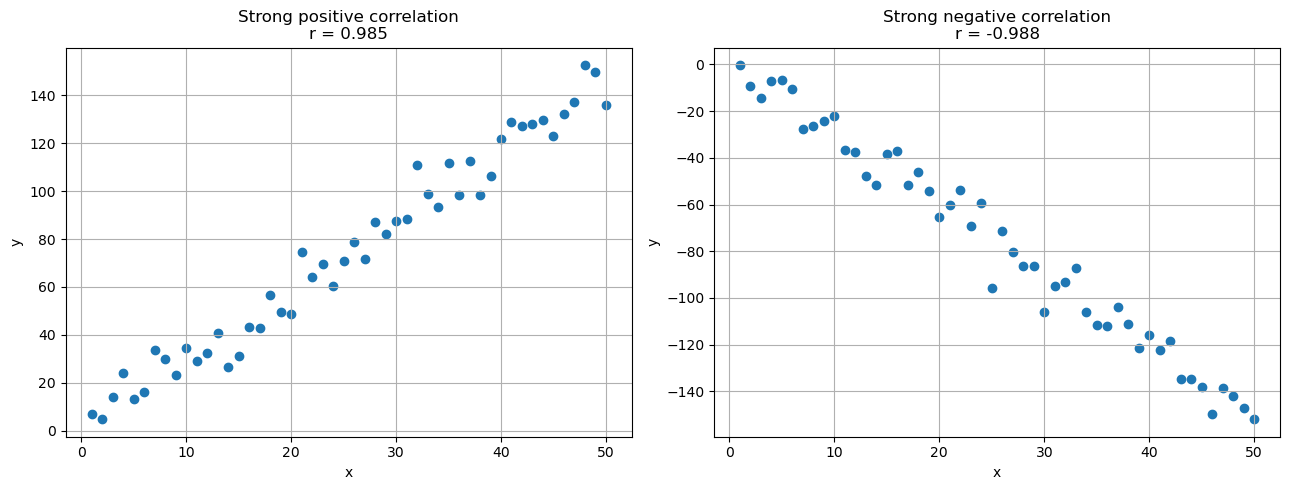

In [7]:
import numpy as np

np.random.seed(42) 

x = np.arange(1, 51)
pos_y = 3 * x + np.random.normal(0, 8, size=len(x))
neg_y = -3 * x + np.random.normal(0, 8, size=len(x))
pos_corr = np.corrcoef(x, pos_y)[0, 1]
neg_corr = np.corrcoef(x, neg_y)[0, 1]

print('Positive correlation:', pos_corr)
print('Negative correlation:', neg_corr)

figure, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(x, pos_y)
axes[0].set_title(f'Strong positive correlation\nr = {pos_corr:.3f}') 
axes[0].set_xlabel('x') 
axes[0].set_ylabel('y') 
axes[0].grid()

axes[1].scatter(x, neg_y) 
axes[1].set_title(f'Strong negative correlation\nr = {neg_corr:.3f}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y') 
axes[1].grid()

plt.tight_layout()
plt.show()

In [ ]:
# The first data set has a correlation coefficient close to 1, showing a strong positive linear relationship. As x increases, y also increases.
# The second dataset has a correlation coefficient close to -1, showing a strong negative linear relationship. As x increases, y decreases.